In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from IPython.display import display

In [2]:
wordpress_report    = "Wordpress Summary/IncrementalTesting/Combination/Wordpress Report - Incremental Combination Summary.csv"
ghost_report = "Ghost Summary/IncrementalTesting/Combination/Ghost Report - Incremental Combination Summary.csv"
drupal_report = "Drupal Summary/IncrementalTesting/Combination/Drupal Report - Incremental Combination Summary.csv"

wordpress = pd.read_csv(wordpress_report)
ghost = pd.read_csv(ghost_report)
drupal = pd.read_csv(drupal_report)

In [3]:
wordpress_avg = wordpress.iloc[-1:].copy()
ghost_avg = ghost.iloc[-1:].copy()
drupal_avg = drupal.iloc[-1:].copy()

wordpress_avg['website'] = 'WordPress'
ghost_avg['website'] = 'Ghost'
drupal_avg['website'] = 'Drupal'

comparison = pd.concat([wordpress_avg, ghost_avg, drupal_avg], ignore_index=True)

In [4]:
cols = ['website', 'avg_response (ms)', 'p95_response (ms)',  'avg_latency (ms)',
        'error_rate (%)', 'throughput (req/s)', 'cache none (%)', 'waf active (%)', 'apdex']

result = comparison[cols].round(3)
result.to_csv("Assets Testing/Incremental/Combination/Comparison Report - Incremental Combination.csv", index=False)

styled = (result.style
          .hide(axis="index")
          .format(precision=3)
          .set_table_styles([
              {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold')]}
          ]))

display(styled)

website,avg_response (ms),p95_response (ms),avg_latency (ms),error_rate (%),throughput (req/s),cache none (%),waf active (%),apdex
WordPress,590.512,1187.800,585.610,100.000,453.862,100.000,99.976,0.759
Ghost,527.608,1063.400,523.964,100.000,510.888,100.000,99.984,0.790
Drupal,620.714,1309.800,616.394,100.000,410.972,100.000,99.976,0.745


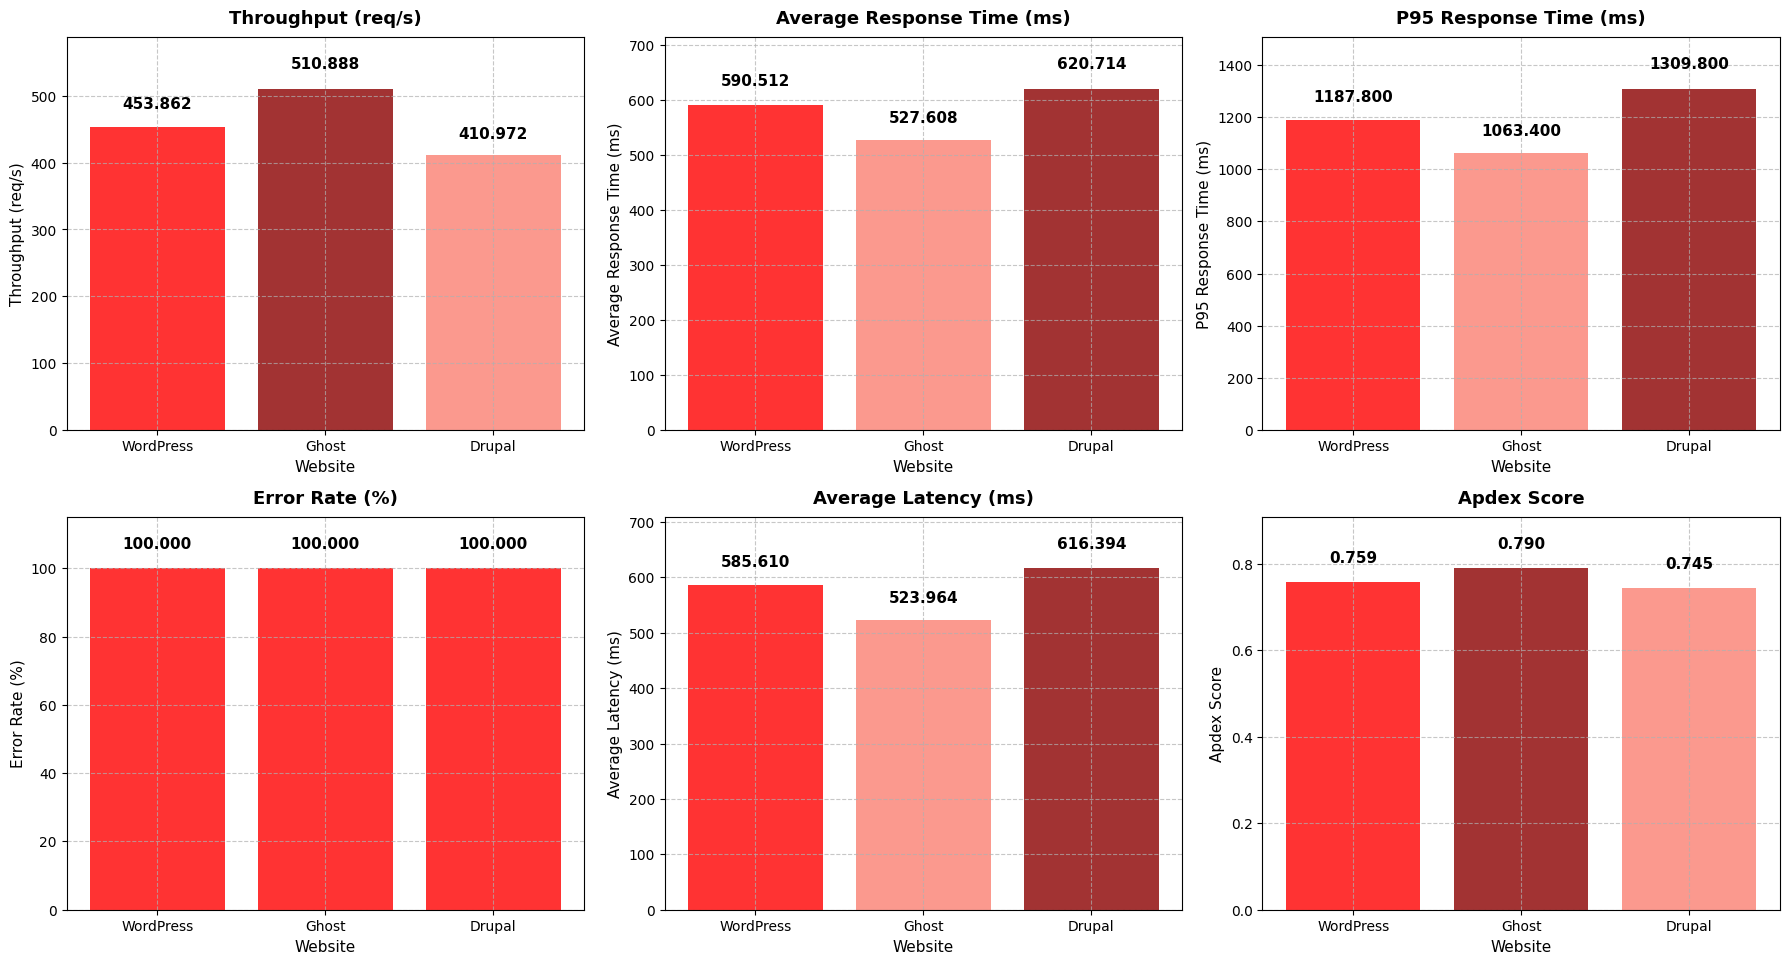

In [5]:
fig, axs = plt.subplots(3, 3, figsize=(18, 15))

metrics = [
    ('throughput (req/s)', 'Throughput (req/s)'         ),
    ('avg_response (ms)',  'Average Response Time (ms)' ),
    ('p95_response (ms)',  'P95 Response Time (ms)'     ),
    ('error_rate (%)',     'Error Rate (%)'             ),
    ('avg_latency (ms)',   'Average Latency (ms)'       ),
    ('apdex',              'Apdex Score'                ),
]

for i, (col, title) in enumerate(metrics):
    row, col_idx = divmod(i, 3)

    values = result[col]
    uniques = sorted(values.unique())
    
    def color_map(v):
        if len(uniques) == 1:
            return 'red'
        elif len(uniques) == 2:
            return 'salmon' if v == uniques[0] else 'darkred'
        else:
            if v == uniques[0]:
                return 'salmon'
            elif v == uniques[-1]:
                return 'darkred'
            else:
                return 'red'
    
    colors = [color_map(v) for v in values]

    bars = axs[row, col_idx].bar(result['website'], result[col], color=colors, alpha=0.8)
    
    axs[row, col_idx].set_title(title, fontsize=13, fontweight='bold', pad=10)
    axs[row, col_idx].set_xlabel("Website", fontsize=11)
    axs[row, col_idx].set_ylabel(title, fontsize=11)
    axs[row, col_idx].grid(True, linestyle='--', alpha=0.7)

    max_val = result[col].max()
    axs[row, col_idx].set_ylim(0, max_val * 1.15)
    
    for bar in bars:
        height = bar.get_height()
        axs[row, col_idx].text(bar.get_x() + bar.get_width()/2, height * 1.05, 
                               f'{height:.3f}', ha='center', va='bottom', 
                               fontsize=11, fontweight='bold')

for j in range(6, 9):
    axs.flat[j].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("Assets Testing/Incremental/Combination/Comparison Report - Incremental Combination.png")
plt.show()

In [6]:
wordpress_result    = "Wordpress Summary/IncrementalTesting/Combination/Wordpress Result - Incremental Combination Summary.csv"
ghost_result = "Ghost Summary/IncrementalTesting/Combination/Ghost Result - Incremental Combination Summary.csv"
drupal_result = "Drupal Summary/IncrementalTesting/Combination/Drupal Result - Incremental Combination Summary.csv"

wordpress_result_monitor = pd.read_csv(wordpress_result)
ghost_result_monitor = pd.read_csv(ghost_result)
drupal_result_monitor = pd.read_csv(drupal_result)

In [7]:
wordpress_result_monitoring = wordpress_result_monitor.iloc[-1:].copy()
ghost_result_monitoring = ghost_result_monitor.iloc[-1:].copy()
drupal_result_monitoring = drupal_result_monitor.iloc[-1:].copy()

wordpress_result_monitoring['Website'] = 'WordPress'
ghost_result_monitoring['Website'] = 'Ghost'
drupal_result_monitoring['Website'] = 'Drupal'

result_comparison = pd.concat([wordpress_result_monitoring, ghost_result_monitoring, drupal_result_monitoring], ignore_index=True)

In [8]:
cols_result_monitoring = ['Website', 'Avg CPU (m)', 'Max CPU (m)', 'Avg Memory (Mi)', 'Max Memory (Mi)', 'Avg Ingress CPU (m)', 'Max Ingress CPU (m)', 'Avg Ingress Memory (Mi)', 'Max Ingress Memory (Mi)', 'ModSecurity Blocked (%)']

result_monitoring = result_comparison[cols_result_monitoring].round(3)
result_monitoring.to_csv("Assets Testing/Incremental/Combination/Comparison Result - Incremental Combination.csv", index=False)

styled = (result_monitoring.style
          .hide(axis="index")
          .format(precision=3)
          .set_table_styles([
              {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold')]}
          ]))

display(styled)

Website,Avg CPU (m),Max CPU (m),Avg Memory (Mi),Max Memory (Mi),Avg Ingress CPU (m),Max Ingress CPU (m),Avg Ingress Memory (Mi),Max Ingress Memory (Mi),ModSecurity Blocked (%)
WordPress,2.214,4.000,267.452,477.000,1386.516,1572.400,86.494,88.600,97.280
Ghost,4.142,13.400,276.020,380.000,1407.568,1557.600,85.698,87.800,96.800
Drupal,21.308,62.000,366.030,471.600,1289.266,1536.000,81.940,84.600,95.728


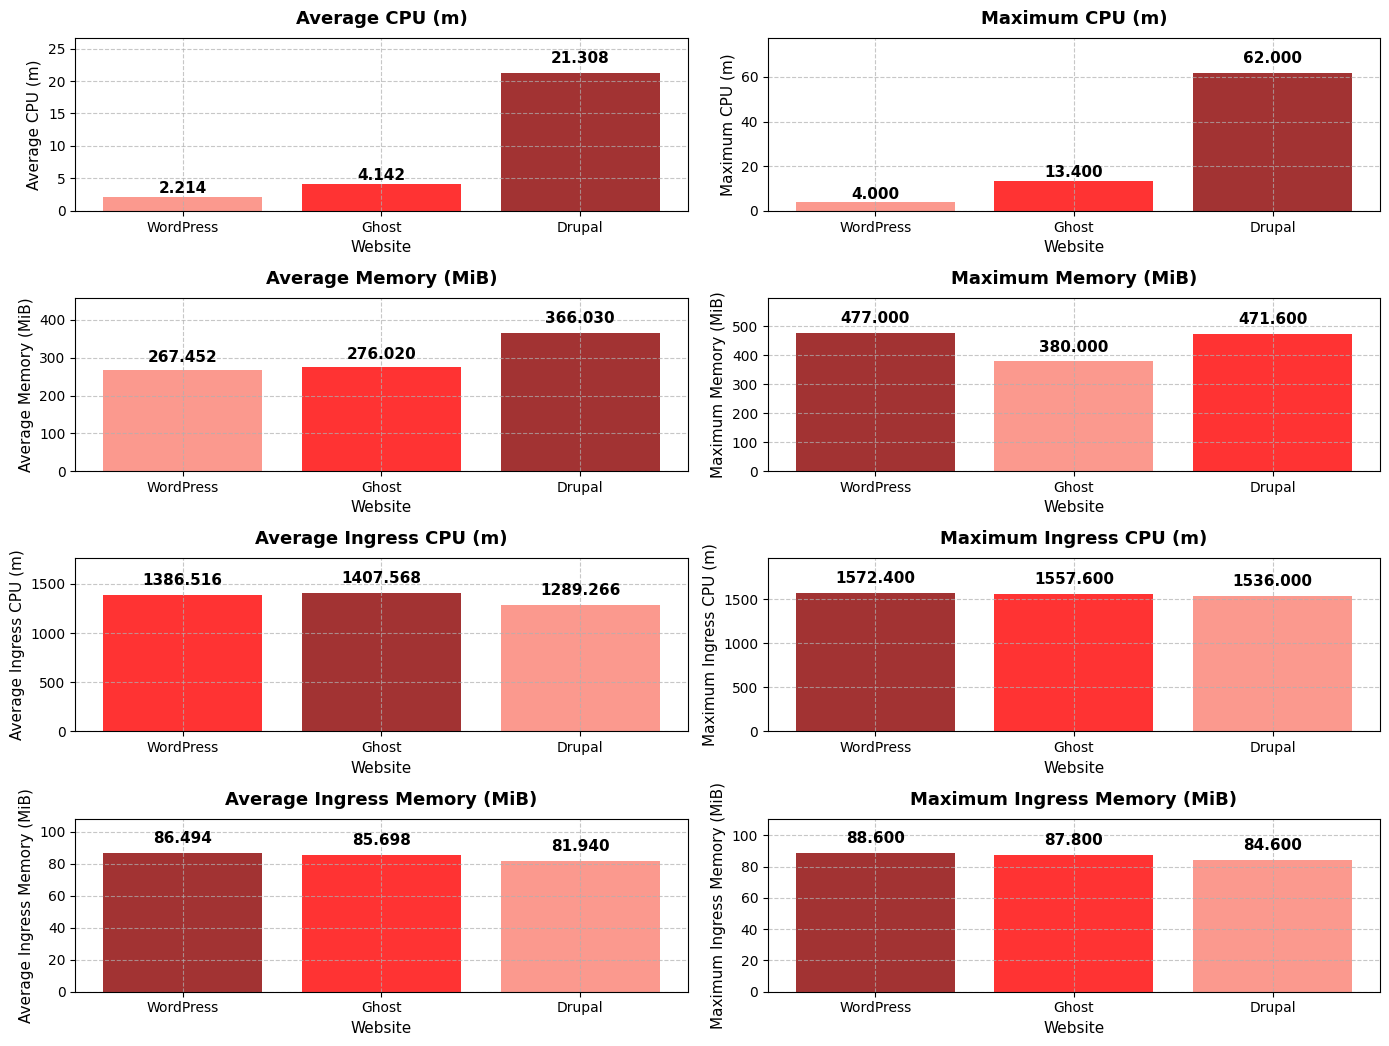

In [9]:
fig, axs = plt.subplots(4, 2, figsize=(14, 11))

metrics = [
    ('Avg CPU (m)',             'Average CPU (m)'              ),
    ('Max CPU (m)',             'Maximum CPU (m)'              ),
    ('Avg Memory (Mi)',         'Average Memory (MiB)'         ),
    ('Max Memory (Mi)',         'Maximum Memory (MiB)'         ),
    ('Avg Ingress CPU (m)',     'Average Ingress CPU (m)'      ),
    ('Max Ingress CPU (m)',     'Maximum Ingress CPU (m)'      ),
    ('Avg Ingress Memory (Mi)', 'Average Ingress Memory (MiB)' ),
    ('Max Ingress Memory (Mi)', 'Maximum Ingress Memory (MiB)' ),
]

for i, (col, title) in enumerate(metrics):
    row, col_idx = divmod(i, 2)

    values = result_monitoring[col]
    uniques = sorted(values.unique())
    
    def color_map(v):
        if len(uniques) == 1:
            return 'red'
        elif len(uniques) == 2:
            return 'salmon' if v == uniques[0] else 'darkred'
        else:
            if v == uniques[0]:
                return 'salmon'
            elif v == uniques[-1]:
                return 'darkred'
            else:
                return 'red'
    
    colors = [color_map(v) for v in values]
        
    bars = axs[row, col_idx].bar(result_monitoring['Website'], result_monitoring[col], color=colors, alpha=0.8)
    
    axs[row, col_idx].set_title(title, fontsize=13, fontweight='bold', pad=10)
    axs[row, col_idx].set_xlabel("Website", fontsize=11)
    axs[row, col_idx].set_ylabel(title, fontsize=11)
    axs[row, col_idx].grid(True, linestyle='--', alpha=0.7)

    max_val = result_monitoring[col].max()
    axs[row, col_idx].set_ylim(0, max_val * 1.25)
    
    for bar in bars:
        height = bar.get_height()
        axs[row, col_idx].text(bar.get_x() + bar.get_width()/2, height * 1.05, 
                               f'{height:.3f}', ha='center', va='bottom', 
                               fontsize=11, fontweight='bold')


plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("Assets Testing/Incremental/Combination/Comparison Result - Incremental Combination.png")
plt.show()

In [10]:
wordpress_kernel    = "Wordpress Summary/IncrementalTesting/Combination/Wordpress Kernel - Incremental Combination Summary.csv"
ghost_kernel = "Ghost Summary/IncrementalTesting/Combination/Ghost Kernel - Incremental Combination Summary.csv"
drupal_kernel = "Drupal Summary/IncrementalTesting/Combination/Drupal Kernel - Incremental Combination Summary.csv"

wordpress_kernel_monitor = pd.read_csv(wordpress_kernel)
ghost_kernel_monitor = pd.read_csv(ghost_kernel)
drupal_kernel_monitor = pd.read_csv(drupal_kernel)

In [11]:
wordpress_kernel_monitoring = wordpress_kernel_monitor.iloc[-1:].copy()
ghost_kernel_monitoring = ghost_kernel_monitor.iloc[-1:].copy()
drupal_kernel_monitoring = drupal_kernel_monitor.iloc[-1:].copy()

wordpress_kernel_monitoring['Website'] = 'WordPress'
ghost_kernel_monitoring['Website'] = 'Ghost'
drupal_kernel_monitoring['Website'] = 'Drupal'

kernel_comparison = pd.concat([wordpress_kernel_monitoring, ghost_kernel_monitoring, drupal_kernel_monitoring], ignore_index=True)

In [12]:
cols_kernel_monitoring = ['Website', 'Avg CPU (%)', 'Max CPU (%)', 'Avg Memory (MB)', 'Max Memory (MB)', 'Avg I/O (S)', 'Max I/O (S)', 'Context Switches']

kernel_monitoring = kernel_comparison[cols_kernel_monitoring].round(3)
kernel_monitoring.to_csv("Assets Testing/Incremental/Combination/Comparison Kernel - Incremental Combination.csv", index=False)

styled = (kernel_monitoring.style
          .hide(axis="index")
          .format(precision=3)
          .set_table_styles([
              {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold')]}
          ]))

display(styled)

Website,Avg CPU (%),Max CPU (%),Avg Memory (MB),Max Memory (MB),Avg I/O (S),Max I/O (S),Context Switches
WordPress,93.660,101.000,4326.172,4349.600,697.652,14794.586,26726.122
Ghost,93.272,101.000,4297.304,4325.600,772.288,16892.000,27961.406
Drupal,89.542,101.000,4211.574,4243.000,1524.614,14785.972,25727.350


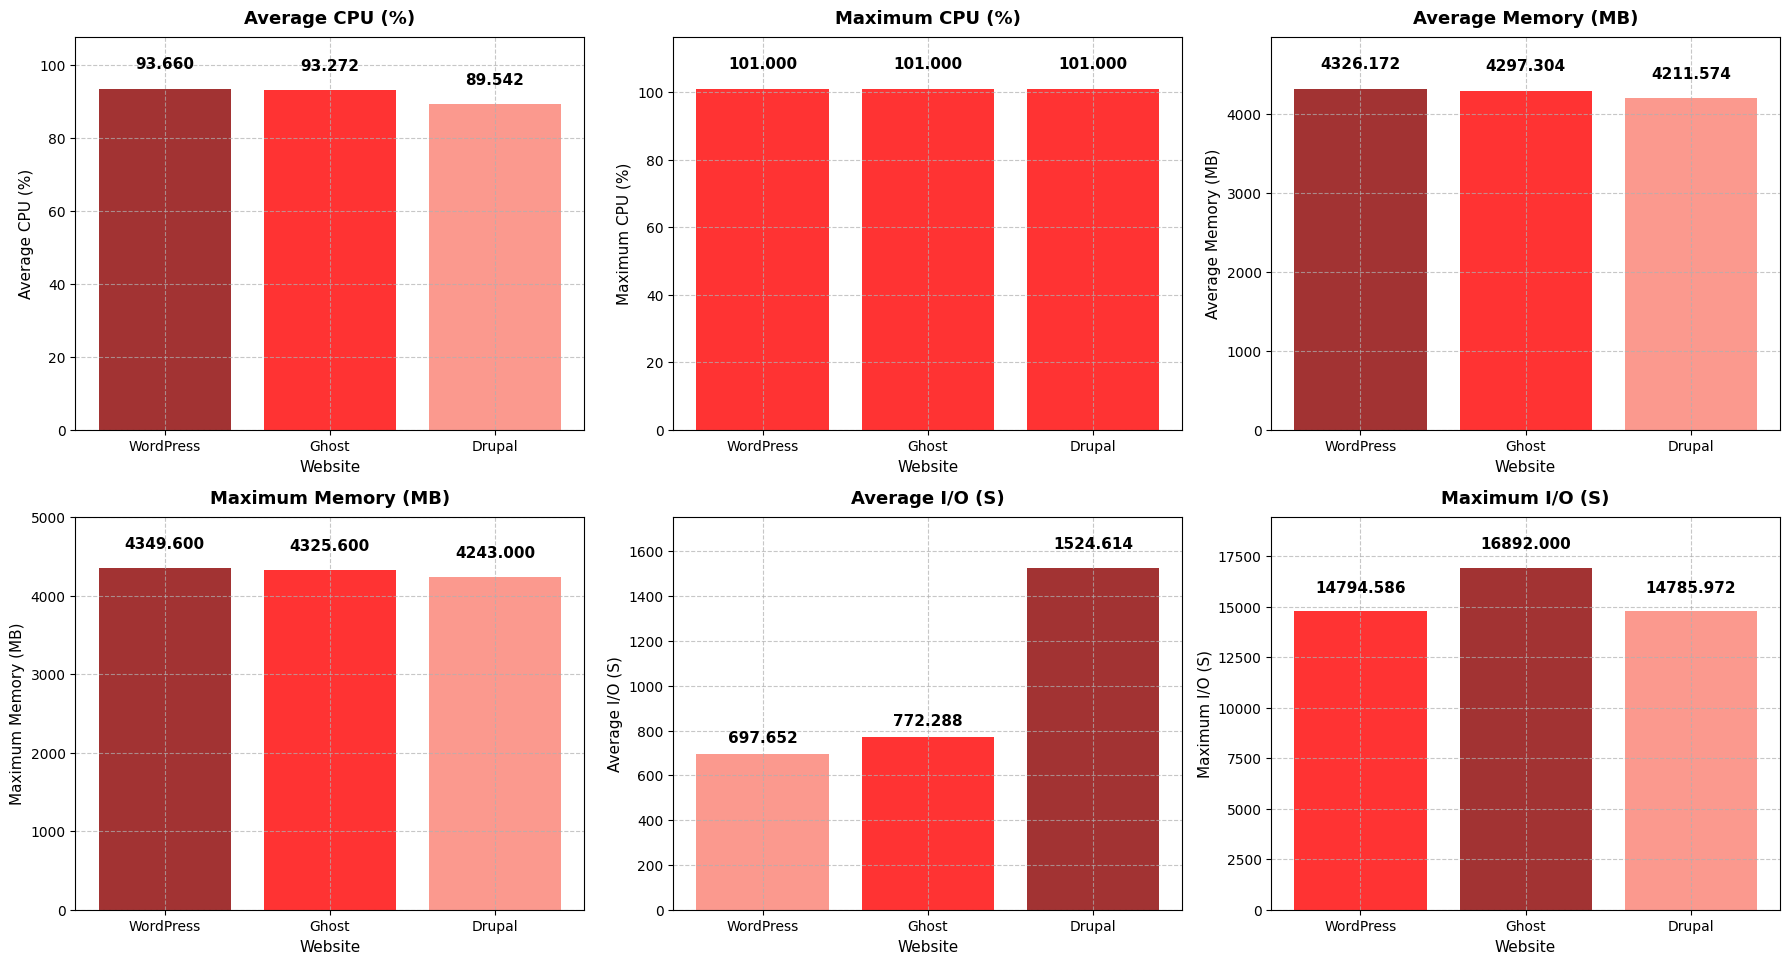

In [13]:
fig, axs = plt.subplots(3, 3, figsize=(18, 15))

metrics = [
    ('Avg CPU (%)',     'Average CPU (%)'     ),
    ('Max CPU (%)',     'Maximum CPU (%)'     ),
    ('Avg Memory (MB)', 'Average Memory (MB)' ),
    ('Max Memory (MB)', 'Maximum Memory (MB)' ),
    ('Avg I/O (S)',     'Average I/O (S)'     ), 
    ('Max I/O (S)',     'Maximum I/O (S)'     ),
]

for i, (col, title) in enumerate(metrics):
    row, col_idx = divmod(i, 3)

    values = kernel_monitoring[col]
    uniques = sorted(values.unique())
    
    def color_map(v):
        if len(uniques) == 1:
            return 'red'
        elif len(uniques) == 2:
            return 'salmon' if v == uniques[0] else 'darkred'
        else:
            if v == uniques[0]:
                return 'salmon'
            elif v == uniques[-1]:
                return 'darkred'
            else:
                return 'red'
    
    colors = [color_map(v) for v in values]

    bars = axs[row, col_idx].bar(kernel_monitoring['Website'], kernel_monitoring[col], color=colors, alpha=0.8)
    
    axs[row, col_idx].set_title(title, fontsize=13, fontweight='bold', pad=10)
    axs[row, col_idx].set_xlabel("Website", fontsize=11)
    axs[row, col_idx].set_ylabel(title, fontsize=11)
    axs[row, col_idx].grid(True, linestyle='--', alpha=0.7)

    max_val = kernel_monitoring[col].max()
    axs[row, col_idx].set_ylim(0, max_val * 1.15)
    
    for bar in bars:
        height = bar.get_height()
        axs[row, col_idx].text(bar.get_x() + bar.get_width()/2, height * 1.05, 
                               f'{height:.3f}', ha='center', va='bottom', 
                               fontsize=11, fontweight='bold')

for j in range(6, 9):
    axs.flat[j].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("Assets Testing/Incremental/Combination/Comparison Kernel - Incremental Combination.png")
plt.show()